===========================================================================
KAGGLE NOTEBOOK - Volatility Forecasting: Moirai, Moirai2, MoiraiMoE
===========================================================================
Copy tung cell vao Kaggle. File nay chi dung ASCII space, khong co U+00A0.
===========================================================================


In [1]:
!git clone https://github.com/SalesforceAIResearch/uni2ts.git uni2ts
!pip install hydra-core jaxtyping -q

Cloning into 'uni2ts'...
remote: Enumerating objects: 1237, done.
remote: Counting objects: 100% (618/618), done.
remote: Compressing objects: 100% (284/284), done.
remote: Total 1237 (delta 439), reused 334 (delta 334), pack-reused 619 (from 2)
Receiving objects: 100% (1237/1237), 9.52 MiB | 22.06 MiB/s, done.
Resolving deltas: 100% (607/607), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 4.7 MB/s eta 0:00:00


In [2]:
BASE = 'uni2ts/src/uni2ts/model'
open(BASE + '/moirai/__init__.py', 'w').write('from .module import MoiraiModule\n\n__all__ = ["MoiraiModule"]\n')
open(BASE + '/moirai2/__init__.py', 'w').write('from .module import Moirai2Module\n\n__all__ = ["Moirai2Module"]\n')
open(BASE + '/moirai_moe/__init__.py', 'w').write('from .module import MoiraiMoEModule\n\n__all__ = ["MoiraiMoEModule"]\n')
print('Patched: moirai, moirai2, moirai_moe __init__.py')

Patched: moirai, moirai2, moirai_moe __init__.py


In [3]:
import sys
import os

uni2ts_src = os.path.abspath('uni2ts/src')
if uni2ts_src not in sys.path:
    sys.path.insert(0, uni2ts_src)

from uni2ts.model.moirai import MoiraiModule
from uni2ts.model.moirai2 import Moirai2Module
from uni2ts.model.moirai_moe import MoiraiMoEModule

print('-> Import thanh cong MoiraiModule, Moirai2Module, MoiraiMoEModule!')
print('-> Numpy version:', __import__('numpy').__version__)
print('-> Torch version:', __import__('torch').__version__)

-> Import thanh cong MoiraiModule, Moirai2Module, MoiraiMoEModule!
-> Numpy version: 2.0.2
-> Torch version: 2.10.0+cu128


In [4]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


class VolatilityDataset(Dataset):
    def __init__(self, df, lookback=60, horizons=None):
        if horizons is None:
            horizons = [1, 3, 5, 10, 21]
        self.lookback = lookback
        self.horizons = horizons

        df = df.sort_values('time').reset_index(drop=True)
        close = df['close'].values

        returns = np.diff(np.log(close)) * 100
        self.returns = np.concatenate([[0.0], returns])

        df['returns'] = self.returns
        self.times = df['time'].values

        # Chi tao mau tu 2010-01-01 tro di (truoc 2010 la burn-in)
        self.valid_indices = df[df['time'] >= '2010-01-01'].index.tolist()
        self.samples = []
        n = len(self.returns)

        for t in self.valid_indices:
            x = self.returns[t - lookback: t]
            y = []
            for h in horizons:
                # Target volatility is standard deviation of 60 days ending at t + h - 2 (inclusive)
                # In Python slice, this corresponds to returns[t + h - 1 - lookback : t + h - 1]
                start_target_idx = t + h - 1 - lookback
                end_target_idx = t + h - 1
                
                # Check boundary to avoid indexing out of bounds at the end of the dataset
                if end_target_idx > n:
                    end_target_idx = n
                    start_target_idx = max(0, n - lookback)
                
                target_r = self.returns[start_target_idx:end_target_idx]
                vol = np.std(target_r)
                y.append(vol)
            self.samples.append({
                'x': torch.tensor(x, dtype=torch.float32),
                'y': torch.tensor(y, dtype=torch.float32),
                'time': self.times[t],
                'log_return': self.returns[t]
            })


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]['x'], self.samples[idx]['y']

In [5]:
def load_and_split_dataset(csv_path, index_name, split_info):
    df = pd.read_csv(csv_path)
    full_ds = VolatilityDataset(df)
    train_size = split_info[index_name]['train']
    val_size = split_info[index_name]['validation']
    test_size = split_info[index_name]['test']
    train_ds = torch.utils.data.Subset(full_ds, range(0, train_size))
    val_ds = torch.utils.data.Subset(full_ds, range(train_size, train_size + val_size))
    test_ds = torch.utils.data.Subset(full_ds, range(train_size + val_size, train_size + val_size + test_size))
    return train_ds, val_ds, test_ds


SPLIT_INFO = {
    'DAX_40':       {'train': 1983, 'validation': 1104, 'test': 972},
    'EuroNext_100': {'train': 2005, 'validation': 1115, 'test': 979},
    'IBEX_35':      {'train': 1815, 'validation': 1362, 'test': 923},
    'KOSPI_index':  {'train': 1944, 'validation': 1109, 'test': 881},
    'Nikkei_225':   {'train': 1677, 'validation': 1174, 'test': 1062},
    'SMI':          {'train': 1987, 'validation': 1135, 'test': 901},
    'snp500':       {'train': 1988, 'validation': 1109, 'test': 927},
    'VN30_INDEX':   {'train': 1971, 'validation': 1096, 'test': 925},
    'VN_INDEX':     {'train': 1964, 'validation': 1103, 'test': 925},
}

In [6]:
import torch.nn as nn
import torch.nn.functional as F


class VolatilityFeatureExtractor(nn.Module):
    def __init__(self, model_type='moirai', size='small', device='cuda', weights_dir=None):
        super().__init__()
        self.model_type = model_type
        self.device = device

        # Xac dinh duong dan tai weights (Online tu HF Hub hoac Offline tu folder cuc bo)
        if weights_dir is not None:
            if model_type == 'moirai':
                pretrained_path = os.path.join(weights_dir, f"moirai-1.1-R-{size}")
            elif model_type == 'moirai2':
                pretrained_path = os.path.join(weights_dir, f"moirai-2.0-R-{size}")
            elif model_type == 'moirai_moe':
                pretrained_path = os.path.join(weights_dir, f"moirai-moe-1.0-R-{size}")
        else:
            if model_type == 'moirai':
                pretrained_path = f"Salesforce/moirai-1.1-R-{size}"
            elif model_type == 'moirai2':
                pretrained_path = f"Salesforce/moirai-2.0-R-{size}"
            elif model_type == 'moirai_moe':
                pretrained_path = f"Salesforce/moirai-moe-1.0-R-{size}"

        if model_type == 'moirai':
            from uni2ts.model.moirai import MoiraiModule
            from uni2ts.common.torch_util import packed_attention_mask
            self.backbone = MoiraiModule.from_pretrained(pretrained_path)
            self.d_model = self.backbone.d_model
            self.packed_attention_mask = packed_attention_mask
            self.max_patch = max(self.backbone.patch_sizes)
        elif model_type == 'moirai2':
            from uni2ts.model.moirai2 import Moirai2Module
            from uni2ts.common.torch_util import packed_causal_attention_mask
            self.backbone = Moirai2Module.from_pretrained(pretrained_path)
            self.d_model = self.backbone.d_model
            self.packed_causal_attention_mask = packed_causal_attention_mask
            self.max_patch = self.backbone.patch_size
        elif model_type == 'moirai_moe':
            from uni2ts.model.moirai_moe import MoiraiMoEModule
            from uni2ts.common.torch_util import packed_causal_attention_mask
            self.backbone = MoiraiMoEModule.from_pretrained(pretrained_path)
            self.d_model = self.backbone.d_model
            self.packed_causal_attention_mask = packed_causal_attention_mask
            self.max_patch = max(self.backbone.patch_sizes)
        else:
            raise ValueError("model_type must be 'moirai', 'moirai2', or 'moirai_moe'")

        for param in self.backbone.parameters():
            param.requires_grad = False
        self.backbone.eval()
        self.backbone.to(device)

    def forward(self, x):
        batch_size = x.shape[0]
        seq_len = x.shape[1]  # 60

        # Moirai 2.0 Small yêu cầu patch_size cố định là 16.
        # Moirai 1.0 và MoiraiMoE hỗ trợ đa patch_size [8, 16, 32, 64, 128]
        patch_size_val = 16
        seq_len_patched = 4  # 64 / 16 = 4 tokens
        pad_len = 64 - seq_len  # 64 - 60 = 4

        # Pad thêm 4 số 0 vào đầu chuỗi 60 ngày để có chuỗi 64 ngày (chia hết cho patch_size 16)
        x_padded = F.pad(x, (pad_len, 0))  # B x 64
        
        # Reshape thành dạng (B, seq_len_patched, patch_size_val) -> (B, 4, 16)
        target_16 = x_padded.view(batch_size, seq_len_patched, patch_size_val).to(self.device)
        
        if self.max_patch > patch_size_val:
            target = F.pad(target_16, (0, self.max_patch - patch_size_val))
            observed_mask = torch.zeros_like(target, dtype=torch.bool)
            observed_mask[:, :, :patch_size_val] = True
        else:
            target = target_16
            observed_mask = torch.ones_like(target, dtype=torch.bool)
        
        sample_id = torch.zeros((batch_size, seq_len_patched), dtype=torch.long, device=self.device)
        time_id = torch.arange(seq_len_patched, dtype=torch.long, device=self.device).unsqueeze(0).repeat(batch_size, 1)
        variate_id = torch.zeros((batch_size, seq_len_patched), dtype=torch.long, device=self.device)

        with torch.no_grad():
            if self.model_type == 'moirai2':
                loc, scale = self.backbone.scaler(target, observed_mask, sample_id, variate_id)
                scaled_target = (target - loc) / scale
                input_tokens = torch.cat([scaled_target, observed_mask.to(torch.float32)], dim=-1)
                reprs = self.backbone.in_proj(input_tokens)
                attn_mask = self.packed_causal_attention_mask(sample_id, time_id)
                reprs = self.backbone.encoder(reprs, attn_mask, time_id=time_id, var_id=variate_id)

            elif self.model_type == 'moirai':
                patch_size_tensor = torch.full((batch_size, seq_len_patched), patch_size_val, dtype=torch.long, device=self.device)
                loc, scale = self.backbone.scaler(target, observed_mask, sample_id, variate_id)
                scaled_target = (target - loc) / scale
                reprs = self.backbone.in_proj(scaled_target, patch_size_tensor)
                attn_mask = self.packed_attention_mask(sample_id)
                reprs = self.backbone.encoder(reprs, attn_mask, time_id=time_id, var_id=variate_id)

            elif self.model_type == 'moirai_moe':
                patch_size_tensor = torch.full((batch_size, seq_len_patched), patch_size_val, dtype=torch.long, device=self.device)
                loc, scale = self.backbone.scaler(target, observed_mask, sample_id, variate_id)
                scaled_target = (target - loc) / scale
                in_reprs = self.backbone.in_proj(scaled_target, patch_size_tensor)
                in_reprs = F.silu(in_reprs)
                in_reprs = self.backbone.feat_proj(in_reprs, patch_size_tensor)
                res_reprs = self.backbone.res_proj(scaled_target, patch_size_tensor)
                reprs = in_reprs + res_reprs
                attn_mask = self.packed_causal_attention_mask(sample_id, time_id)
                reprs = self.backbone.encoder(reprs, attn_mask, time_id=time_id, var_id=variate_id)

        z = torch.mean(reprs, dim=1)
        return z

In [7]:
class VolatilityRegressionModel(nn.Module):
    def __init__(self, extractor, hidden_dim=256, output_dim=5):
        super().__init__()
        self.extractor = extractor
        self.mlp = nn.Sequential(
            nn.Linear(extractor.d_model, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        z = self.extractor(x)
        return self.mlp(z)

In [8]:
def train_model(model, train_loader, val_loader, epochs=50, lr=1e-3, device='cuda'):
    model.to(device)
    optimizer = torch.optim.AdamW(model.mlp.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.MSELoss()
    best_val_loss = float('inf')
    best_state = None
    patience = 7
    patience_counter = 0

    for epoch in range(epochs):
        model.mlp.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            pred = model(batch_x)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_x.size(0)
        train_loss /= len(train_loader.dataset)

        model.mlp.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                pred = model(batch_x)
                loss = criterion(pred, batch_y)
                val_loss += loss.item() * batch_x.size(0)
        val_loss /= len(val_loader.dataset)

        print('Epoch %02d | Train: %.4f | Val: %.4f' % (epoch + 1, train_loss, val_loss))

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.mlp.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('-> Early stopping!')
                break

    model.mlp.load_state_dict(best_state)
    return model

In [9]:
def evaluate_model(model, test_loader, device='cuda'):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            pred = model(batch_x)
            all_preds.append(pred.cpu().numpy())
            all_targets.append(batch_y.numpy())
    preds = np.concatenate(all_preds, axis=0)
    targets = np.concatenate(all_targets, axis=0)
    metrics_summary = {}
    for idx, h in enumerate([1, 3, 5, 10, 21]):
        p_h = preds[:, idx]
        t_h = targets[:, idx]
        p_c = np.clip(p_h, 1e-5, None)
        t_c = np.clip(t_h, 1e-5, None)
        mse = np.mean((p_h - t_h) ** 2)
        mae = np.mean(np.abs(p_h - t_h))
        q_like = np.mean((t_c ** 2) / (p_c ** 2) - np.log((t_c ** 2) / (p_c ** 2)) - 1)
        metrics_summary['h_' + str(h)] = {'MSE': mse, 'MAE': mae, 'Q-LIKE': q_like}
    return metrics_summary, preds, targets

In [10]:
import os

def run_comparison_pipeline(csv_path, index_name, device='cuda', weights_dir=None, output_dir='/kaggle/working/predictions'):
    print('=== INDEX: ' + index_name + ' ===')
    train_ds, val_ds, test_ds = load_and_split_dataset(csv_path, index_name, SPLIT_INFO)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
    results = {}
    
    # Tạo thư mục đầu ra nếu chưa có
    os.makedirs(output_dir, exist_ok=True)
    
    for m_type in ['moirai', 'moirai2', 'moirai_moe']:
        print('--- Model: ' + m_type.upper() + ' ---')
        extractor = VolatilityFeatureExtractor(model_type=m_type, size='small', device=device, weights_dir=weights_dir)
        model = VolatilityRegressionModel(extractor=extractor)
        model = train_model(model, train_loader, val_loader, epochs=30, device=device)
        metrics, preds, targets = evaluate_model(model, test_loader, device=device)
        results[m_type] = {'metrics': metrics, 'preds': preds, 'targets': targets}

        # Lưu file CSV kết quả cho từng mô hình và từng chỉ số
        csv_rows = []
        full_ds = test_ds.dataset
        for k, idx in enumerate(test_ds.indices):
            sample = full_ds.samples[idx]
            for h_idx, h in enumerate([1, 3, 5, 10, 21]):
                csv_rows.append({
                    'time': sample['time'],
                    'log_return': sample['log_return'],
                    'horizon': h,
                    'true_volatility': targets[k, h_idx],
                    'predict_volatility': preds[k, h_idx]
                })
        df_out = pd.DataFrame(csv_rows)
        csv_filename = os.path.join(output_dir, f"{index_name}_{m_type}_predictions.csv")
        df_out.to_csv(csv_filename, index=False)
        print(f"Saved: {csv_filename}")

    return results

In [12]:
import matplotlib.pyplot as plt


def plot_and_print_results(results, index_name):
    for metric_name in ['MSE', 'MAE', 'Q-LIKE']:
        print(metric_name + ':')
        for h in [1, 3, 5, 10, 21]:
            row = '  h=' + str(h) + '  '
            for m_type in results:
                val = results[m_type]['metrics']['h_' + str(h)][metric_name]
                row += m_type + ': %.6f  ' % val
            print(row)

    plt.figure(figsize=(15, 6))
    plt.plot(results['moirai']['targets'][:, 4], label='Actual', color='black', linewidth=1.5)
    for m_type, color in [('moirai', 'blue'), ('moirai2', 'green'), ('moirai_moe', 'red')]:
        plt.plot(results[m_type]['preds'][:, 4], label=m_type.upper(), color=color, alpha=0.7, linestyle='--')
    plt.title('Realized Volatility h=21 - ' + index_name)
    plt.xlabel('Time Steps (Test Set)')
    plt.ylabel('Volatility (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Bắt đầu huấn luyện cho: DAX_40
=== INDEX: DAX_40 ===
--- Model: MOIRAI ---
Loading weights from local directory
Epoch 01 | Train: 0.2416 | Val: 0.1800
Epoch 02 | Train: 0.0546 | Val: 0.1481
Epoch 03 | Train: 0.0463 | Val: 0.1258
Epoch 04 | Train: 0.0389 | Val: 0.1302
Epoch 05 | Train: 0.0350 | Val: 0.1235
Epoch 06 | Train: 0.0326 | Val: 0.1074
Epoch 07 | Train: 0.0287 | Val: 0.1142
Epoch 08 | Train: 0.0273 | Val: 0.1089
Epoch 09 | Train: 0.0288 | Val: 0.1021
Epoch 10 | Train: 0.0245 | Val: 0.1049
Epoch 11 | Train: 0.0235 | Val: 0.1129
Epoch 12 | Train: 0.0219 | Val: 0.1129
Epoch 13 | Train: 0.0237 | Val: 0.1094
Epoch 14 | Train: 0.0204 | Val: 0.1069
Epoch 15 | Train: 0.0218 | Val: 0.1030
Epoch 16 | Train: 0.0203 | Val: 0.1053
-> Early stopping!
Saved: /kaggle/working/predictions/DAX_40_moirai_predictions.csv
--- Model: MOIRAI2 ---
Loading weights from local directory
Epoch 01 | Train: 0.1646 | Val: 0.0928
Epoch 02 | Train: 0.0299 | Val: 0.0749
Epoch 03 | Train: 0.0232 | Val: 0.0583
Ep

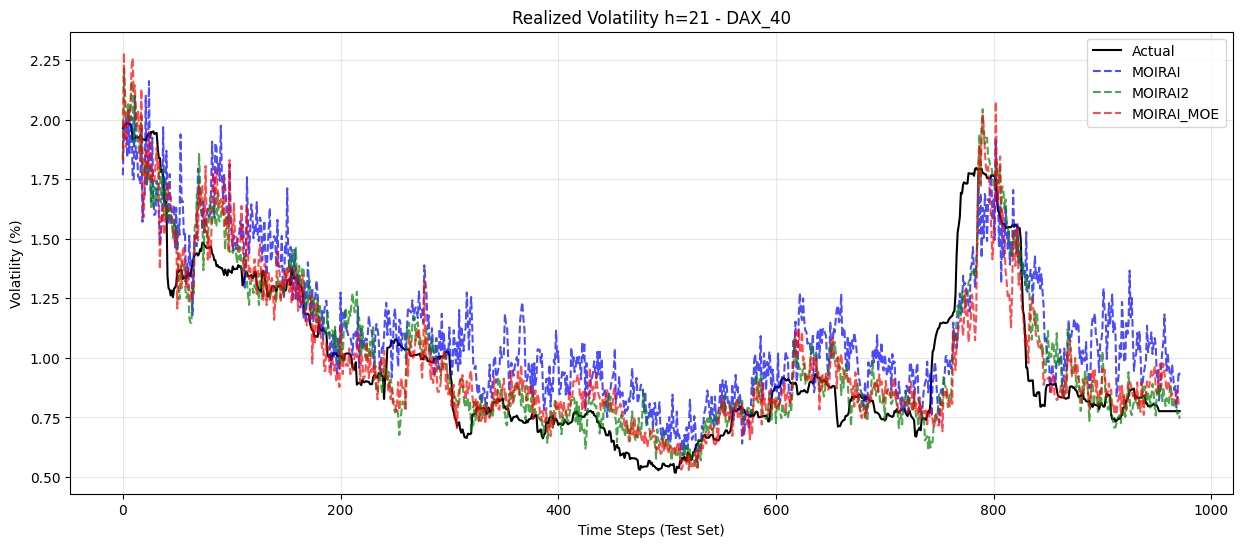


Bắt đầu huấn luyện cho: EuroNext_100
=== INDEX: EuroNext_100 ===
--- Model: MOIRAI ---
Loading weights from local directory
Epoch 01 | Train: 0.1815 | Val: 0.1641
Epoch 02 | Train: 0.0437 | Val: 0.1322
Epoch 03 | Train: 0.0382 | Val: 0.1245
Epoch 04 | Train: 0.0323 | Val: 0.1195
Epoch 05 | Train: 0.0301 | Val: 0.1152
Epoch 06 | Train: 0.0282 | Val: 0.1166
Epoch 07 | Train: 0.0272 | Val: 0.1098
Epoch 08 | Train: 0.0244 | Val: 0.1076
Epoch 09 | Train: 0.0233 | Val: 0.1047
Epoch 10 | Train: 0.0222 | Val: 0.0956
Epoch 11 | Train: 0.0215 | Val: 0.1008
Epoch 12 | Train: 0.0206 | Val: 0.1000
Epoch 13 | Train: 0.0243 | Val: 0.1063
Epoch 14 | Train: 0.0208 | Val: 0.0999
Epoch 15 | Train: 0.0196 | Val: 0.1020
Epoch 16 | Train: 0.0200 | Val: 0.0982
Epoch 17 | Train: 0.0177 | Val: 0.0958
-> Early stopping!
Saved: /kaggle/working/predictions/EuroNext_100_moirai_predictions.csv
--- Model: MOIRAI2 ---
Loading weights from local directory
Epoch 01 | Train: 0.1476 | Val: 0.0901
Epoch 02 | Train: 0.027

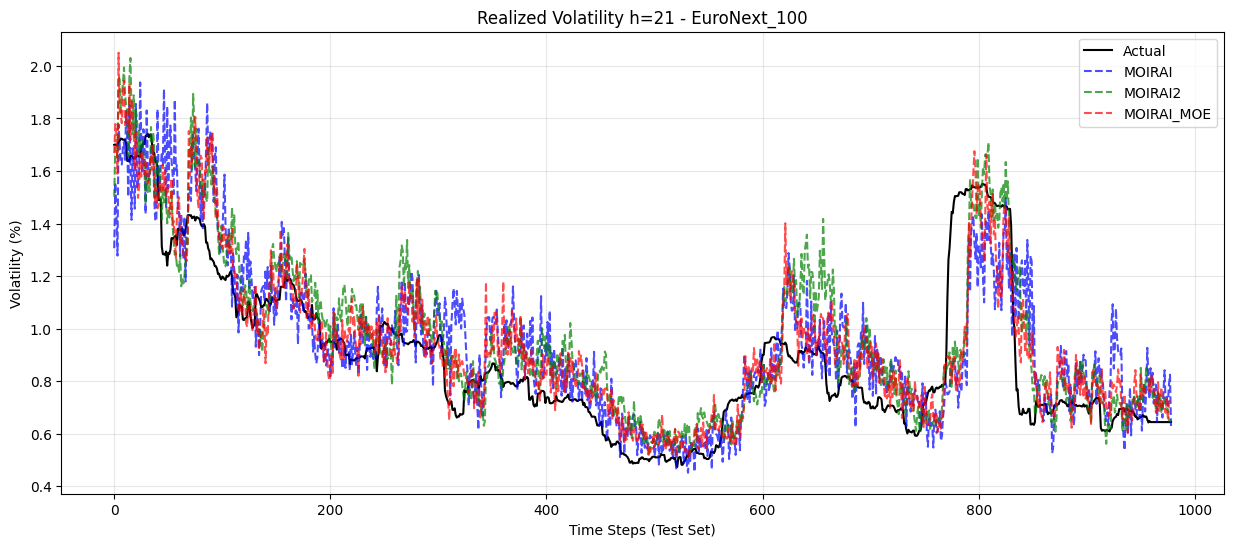


Bắt đầu huấn luyện cho: IBEX_35
=== INDEX: IBEX_35 ===
--- Model: MOIRAI ---
Loading weights from local directory
Epoch 01 | Train: 0.3666 | Val: 0.1837
Epoch 02 | Train: 0.1166 | Val: 0.1409
Epoch 03 | Train: 0.0938 | Val: 0.1261
Epoch 04 | Train: 0.0807 | Val: 0.1326
Epoch 05 | Train: 0.0753 | Val: 0.1208
Epoch 06 | Train: 0.0719 | Val: 0.1119
Epoch 07 | Train: 0.0629 | Val: 0.1149
Epoch 08 | Train: 0.0620 | Val: 0.1101
Epoch 09 | Train: 0.0581 | Val: 0.1066
Epoch 10 | Train: 0.0532 | Val: 0.1076
Epoch 11 | Train: 0.0522 | Val: 0.1089
Epoch 12 | Train: 0.0501 | Val: 0.1063
Epoch 13 | Train: 0.0480 | Val: 0.1036
Epoch 14 | Train: 0.0457 | Val: 0.1083
Epoch 15 | Train: 0.0450 | Val: 0.1032
Epoch 16 | Train: 0.0449 | Val: 0.1056
Epoch 17 | Train: 0.0414 | Val: 0.0989
Epoch 18 | Train: 0.0390 | Val: 0.0985
Epoch 19 | Train: 0.0413 | Val: 0.0996
Epoch 20 | Train: 0.0386 | Val: 0.1020
Epoch 21 | Train: 0.0385 | Val: 0.0984
Epoch 22 | Train: 0.0370 | Val: 0.0958
Epoch 23 | Train: 0.0347 | 

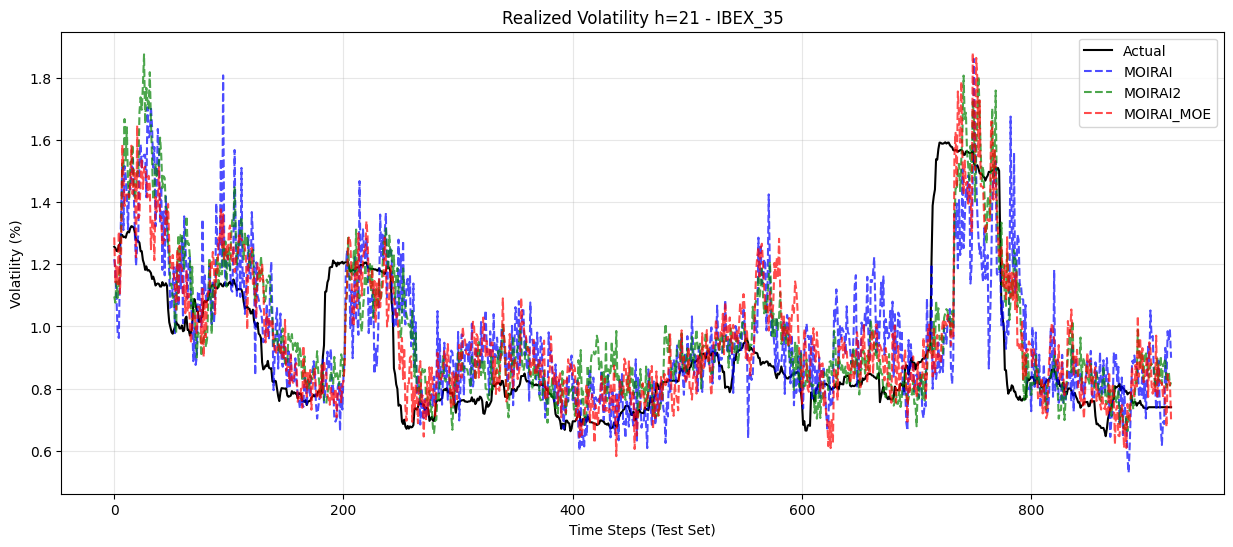


Bắt đầu huấn luyện cho: KOSPI_index
=== INDEX: KOSPI_index ===
--- Model: MOIRAI ---
Loading weights from local directory
Epoch 01 | Train: 0.1347 | Val: 0.1047
Epoch 02 | Train: 0.0294 | Val: 0.0790
Epoch 03 | Train: 0.0221 | Val: 0.0909
Epoch 04 | Train: 0.0206 | Val: 0.0778
Epoch 05 | Train: 0.0180 | Val: 0.0773
Epoch 06 | Train: 0.0166 | Val: 0.0846
Epoch 07 | Train: 0.0160 | Val: 0.0734
Epoch 08 | Train: 0.0153 | Val: 0.0651
Epoch 09 | Train: 0.0130 | Val: 0.0708
Epoch 10 | Train: 0.0132 | Val: 0.0637
Epoch 11 | Train: 0.0134 | Val: 0.0658
Epoch 12 | Train: 0.0127 | Val: 0.0649
Epoch 13 | Train: 0.0111 | Val: 0.0589
Epoch 14 | Train: 0.0117 | Val: 0.0615
Epoch 15 | Train: 0.0116 | Val: 0.0564
Epoch 16 | Train: 0.0110 | Val: 0.0586
Epoch 17 | Train: 0.0109 | Val: 0.0550
Epoch 18 | Train: 0.0099 | Val: 0.0587
Epoch 19 | Train: 0.0103 | Val: 0.0622
Epoch 20 | Train: 0.0101 | Val: 0.0529
Epoch 21 | Train: 0.0098 | Val: 0.0580
Epoch 22 | Train: 0.0097 | Val: 0.0578
Epoch 23 | Train: 0

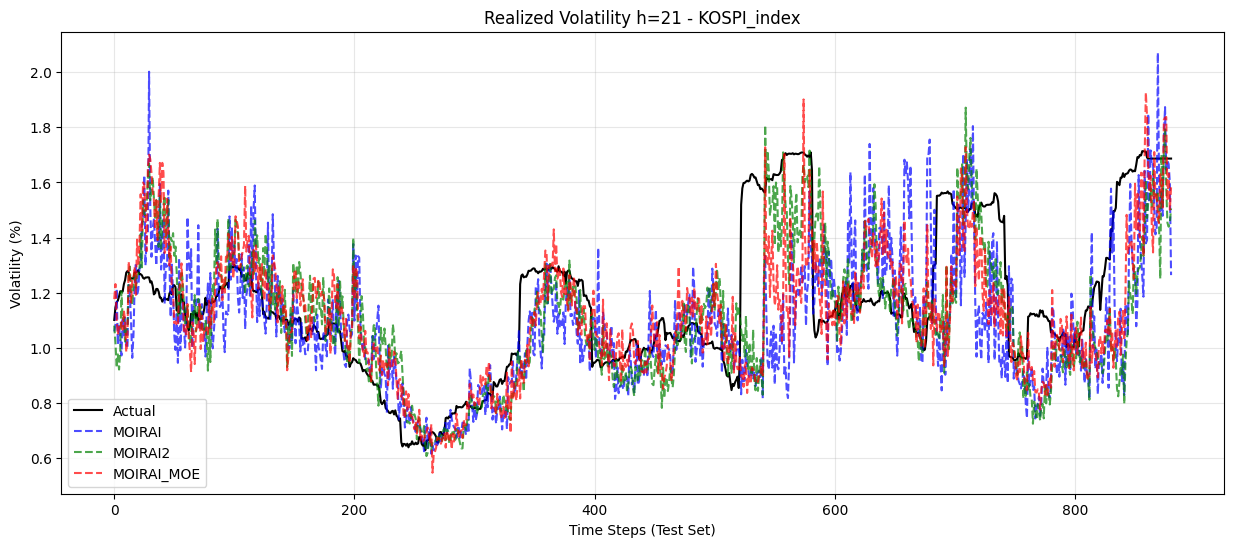


Bắt đầu huấn luyện cho: Nikkei_225
=== INDEX: Nikkei_225 ===
--- Model: MOIRAI ---
Loading weights from local directory
Epoch 01 | Train: 0.3610 | Val: 0.0954
Epoch 02 | Train: 0.0973 | Val: 0.0748
Epoch 03 | Train: 0.0796 | Val: 0.0650
Epoch 04 | Train: 0.0680 | Val: 0.0700
Epoch 05 | Train: 0.0649 | Val: 0.0615
Epoch 06 | Train: 0.0599 | Val: 0.0591
Epoch 07 | Train: 0.0556 | Val: 0.0613
Epoch 08 | Train: 0.0556 | Val: 0.0614
Epoch 09 | Train: 0.0532 | Val: 0.0768
Epoch 10 | Train: 0.0487 | Val: 0.0586
Epoch 11 | Train: 0.0468 | Val: 0.0607
Epoch 12 | Train: 0.0483 | Val: 0.0590
Epoch 13 | Train: 0.0451 | Val: 0.0585
Epoch 14 | Train: 0.0406 | Val: 0.0583
Epoch 15 | Train: 0.0434 | Val: 0.0600
Epoch 16 | Train: 0.0412 | Val: 0.0586
Epoch 17 | Train: 0.0382 | Val: 0.0549
Epoch 18 | Train: 0.0384 | Val: 0.0553
Epoch 19 | Train: 0.0370 | Val: 0.0573
Epoch 20 | Train: 0.0374 | Val: 0.0605
Epoch 21 | Train: 0.0361 | Val: 0.0542
Epoch 22 | Train: 0.0335 | Val: 0.0538
Epoch 23 | Train: 0.0

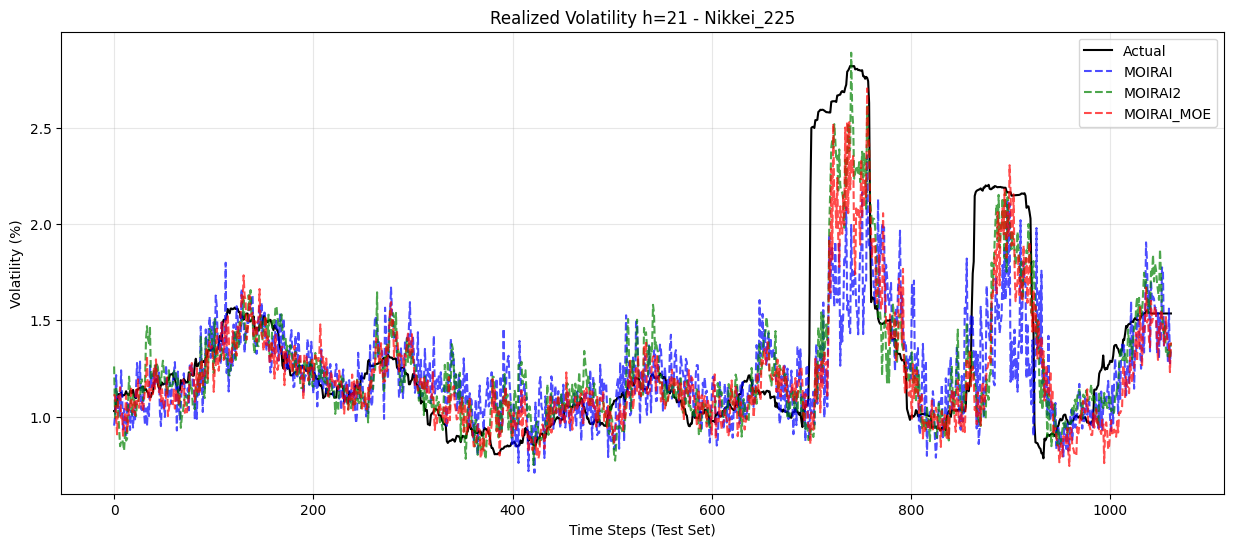


Bắt đầu huấn luyện cho: SMI
=== INDEX: SMI ===
--- Model: MOIRAI ---
Loading weights from local directory
Epoch 01 | Train: 0.1296 | Val: 0.0854
Epoch 02 | Train: 0.0404 | Val: 0.0656
Epoch 03 | Train: 0.0328 | Val: 0.0549
Epoch 04 | Train: 0.0294 | Val: 0.0561
Epoch 05 | Train: 0.0252 | Val: 0.0565
Epoch 06 | Train: 0.0237 | Val: 0.0456
Epoch 07 | Train: 0.0214 | Val: 0.0560
Epoch 08 | Train: 0.0209 | Val: 0.0431
Epoch 09 | Train: 0.0205 | Val: 0.0454
Epoch 10 | Train: 0.0183 | Val: 0.0515
Epoch 11 | Train: 0.0183 | Val: 0.0421
Epoch 12 | Train: 0.0166 | Val: 0.0512
Epoch 13 | Train: 0.0164 | Val: 0.0392
Epoch 14 | Train: 0.0163 | Val: 0.0474
Epoch 15 | Train: 0.0151 | Val: 0.0427
Epoch 16 | Train: 0.0144 | Val: 0.0444
Epoch 17 | Train: 0.0155 | Val: 0.0420
Epoch 18 | Train: 0.0135 | Val: 0.0487
Epoch 19 | Train: 0.0146 | Val: 0.0403
Epoch 20 | Train: 0.0132 | Val: 0.0429
-> Early stopping!
Saved: /kaggle/working/predictions/SMI_moirai_predictions.csv
--- Model: MOIRAI2 ---
Loading w

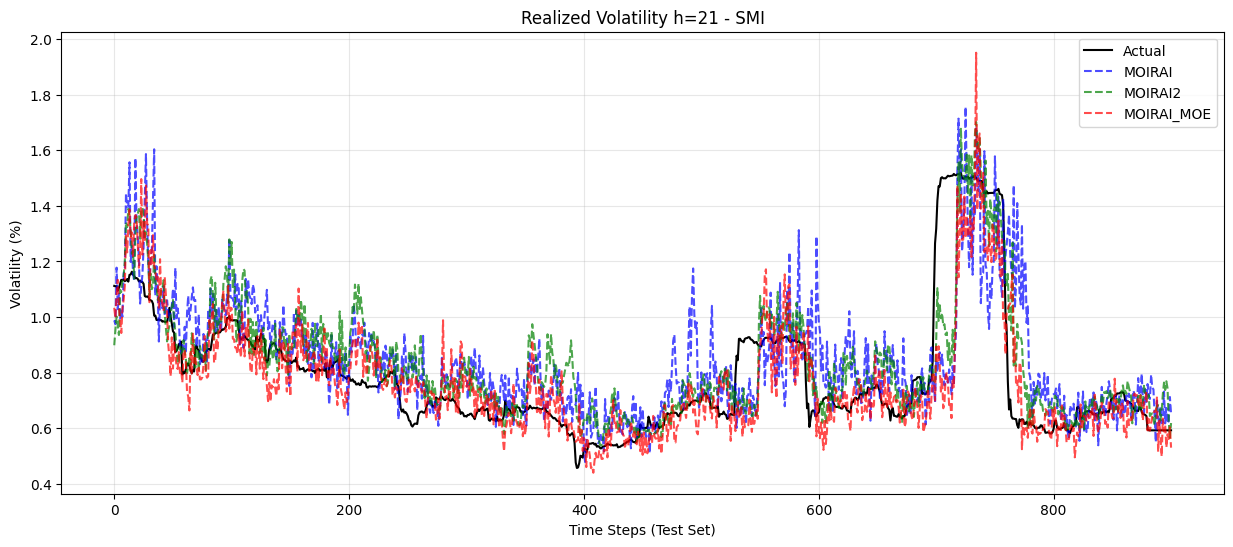


Bắt đầu huấn luyện cho: snp500
=== INDEX: snp500 ===
--- Model: MOIRAI ---
Loading weights from local directory
Epoch 01 | Train: 0.1314 | Val: 0.3505
Epoch 02 | Train: 0.0324 | Val: 0.3040
Epoch 03 | Train: 0.0255 | Val: 0.2829
Epoch 04 | Train: 0.0234 | Val: 0.2731
Epoch 05 | Train: 0.0212 | Val: 0.2623
Epoch 06 | Train: 0.0183 | Val: 0.2548
Epoch 07 | Train: 0.0179 | Val: 0.2453
Epoch 08 | Train: 0.0172 | Val: 0.2405
Epoch 09 | Train: 0.0154 | Val: 0.2457
Epoch 10 | Train: 0.0154 | Val: 0.2309
Epoch 11 | Train: 0.0147 | Val: 0.2400
Epoch 12 | Train: 0.0144 | Val: 0.2326
Epoch 13 | Train: 0.0140 | Val: 0.2469
Epoch 14 | Train: 0.0134 | Val: 0.2331
Epoch 15 | Train: 0.0134 | Val: 0.2440
Epoch 16 | Train: 0.0136 | Val: 0.2175
Epoch 17 | Train: 0.0122 | Val: 0.2185
Epoch 18 | Train: 0.0116 | Val: 0.2482
Epoch 19 | Train: 0.0118 | Val: 0.2281
Epoch 20 | Train: 0.0118 | Val: 0.2274
Epoch 21 | Train: 0.0110 | Val: 0.2176
Epoch 22 | Train: 0.0105 | Val: 0.2364
Epoch 23 | Train: 0.0111 | Va

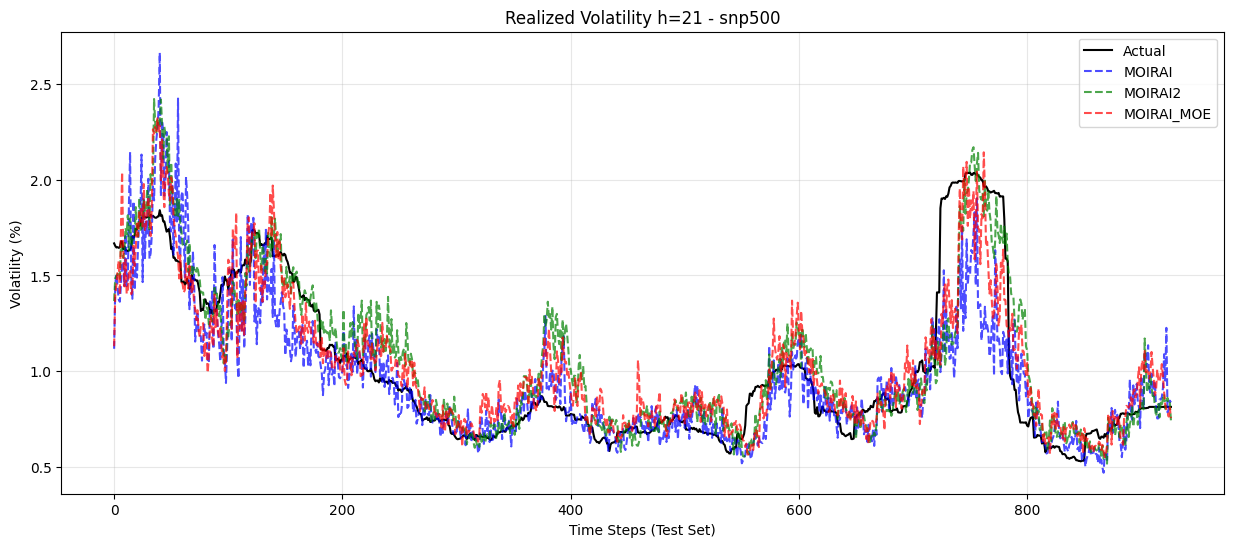


Bắt đầu huấn luyện cho: VN30_INDEX
=== INDEX: VN30_INDEX ===
--- Model: MOIRAI ---
Loading weights from local directory
Epoch 01 | Train: 0.1518 | Val: 0.0909
Epoch 02 | Train: 0.0352 | Val: 0.0694
Epoch 03 | Train: 0.0294 | Val: 0.0719
Epoch 04 | Train: 0.0254 | Val: 0.0583
Epoch 05 | Train: 0.0235 | Val: 0.0546
Epoch 06 | Train: 0.0210 | Val: 0.0607
Epoch 07 | Train: 0.0204 | Val: 0.0618
Epoch 08 | Train: 0.0196 | Val: 0.0585
Epoch 09 | Train: 0.0175 | Val: 0.0570
Epoch 10 | Train: 0.0173 | Val: 0.0536
Epoch 11 | Train: 0.0190 | Val: 0.0626
Epoch 12 | Train: 0.0167 | Val: 0.0523
Epoch 13 | Train: 0.0167 | Val: 0.0488
Epoch 14 | Train: 0.0162 | Val: 0.0554
Epoch 15 | Train: 0.0148 | Val: 0.0522
Epoch 16 | Train: 0.0148 | Val: 0.0489
Epoch 17 | Train: 0.0149 | Val: 0.0596
Epoch 18 | Train: 0.0140 | Val: 0.0502
Epoch 19 | Train: 0.0145 | Val: 0.0523
Epoch 20 | Train: 0.0156 | Val: 0.0489
-> Early stopping!
Saved: /kaggle/working/predictions/VN30_INDEX_moirai_predictions.csv
--- Model: 

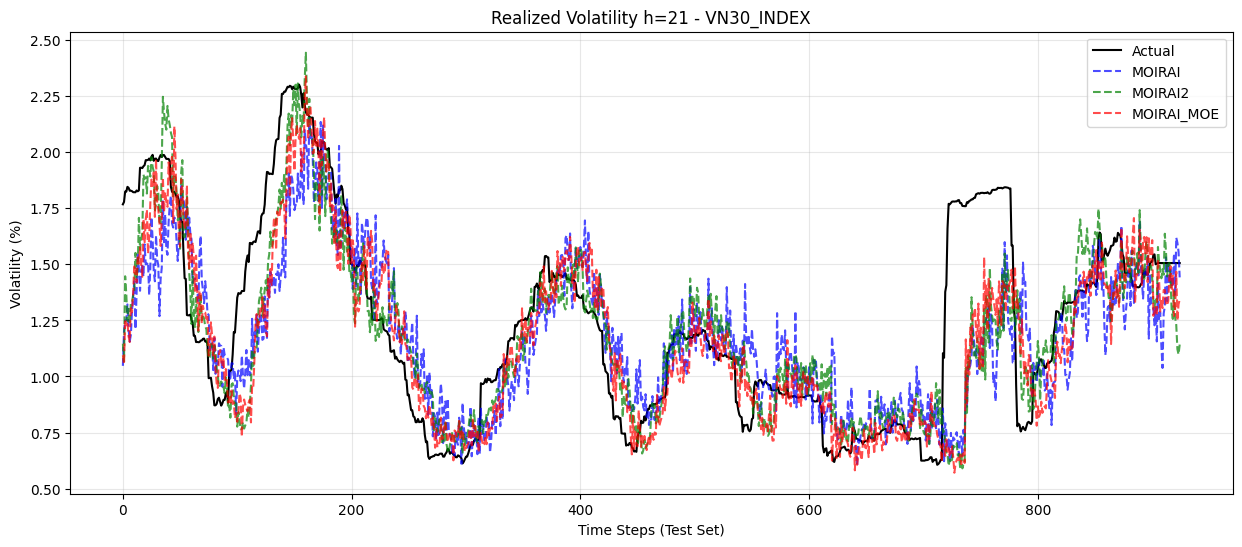


Bắt đầu huấn luyện cho: VN_INDEX
=== INDEX: VN_INDEX ===
--- Model: MOIRAI ---
Loading weights from local directory
Epoch 01 | Train: 0.1497 | Val: 0.0831
Epoch 02 | Train: 0.0354 | Val: 0.0729
Epoch 03 | Train: 0.0291 | Val: 0.0567
Epoch 04 | Train: 0.0248 | Val: 0.0563
Epoch 05 | Train: 0.0225 | Val: 0.0509
Epoch 06 | Train: 0.0210 | Val: 0.0565
Epoch 07 | Train: 0.0212 | Val: 0.0505
Epoch 08 | Train: 0.0190 | Val: 0.0601
Epoch 09 | Train: 0.0186 | Val: 0.0563
Epoch 10 | Train: 0.0188 | Val: 0.0570
Epoch 11 | Train: 0.0171 | Val: 0.0553
Epoch 12 | Train: 0.0167 | Val: 0.0497
Epoch 13 | Train: 0.0160 | Val: 0.0558
Epoch 14 | Train: 0.0163 | Val: 0.0525
Epoch 15 | Train: 0.0158 | Val: 0.0481
Epoch 16 | Train: 0.0154 | Val: 0.0497
Epoch 17 | Train: 0.0148 | Val: 0.0514
Epoch 18 | Train: 0.0140 | Val: 0.0513
Epoch 19 | Train: 0.0139 | Val: 0.0599
Epoch 20 | Train: 0.0141 | Val: 0.0492
Epoch 21 | Train: 0.0136 | Val: 0.0481
Epoch 22 | Train: 0.0159 | Val: 0.0539
Epoch 23 | Train: 0.0134 

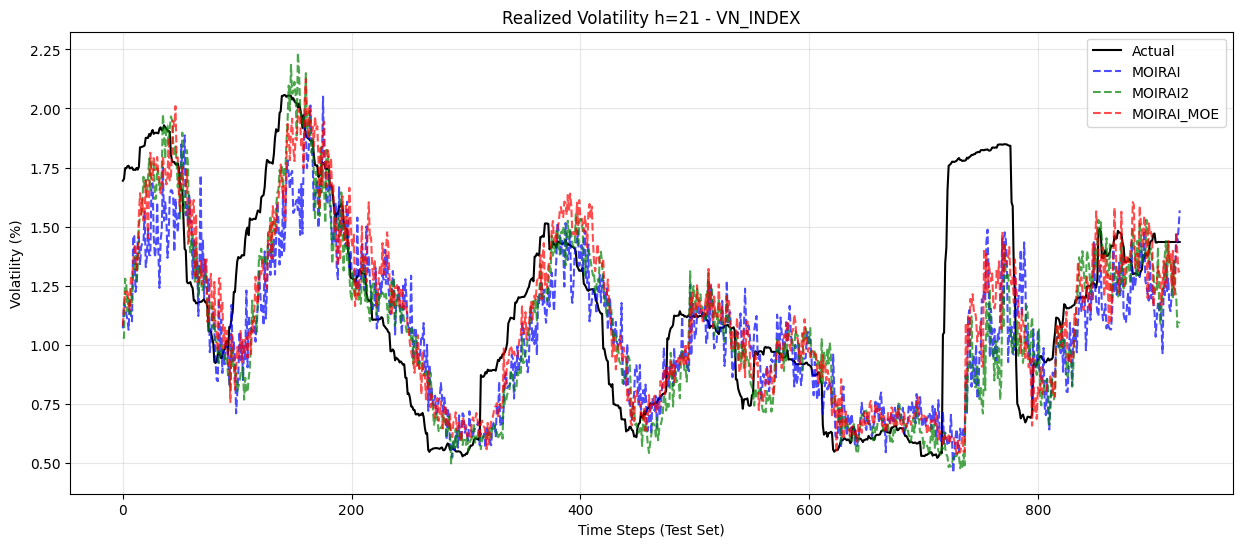


Đã hoàn thành chạy cho toàn bộ dataset!
Các file dự đoán được lưu tại: /kaggle/working/predictions


In [13]:
import os

# Duong dan thu muc weights offline ban da tai len Kaggle
WEIGHTS_DIR = '/kaggle/input/datasets/trnhngv/weights/weights'

# Thu muc chua tat ca file CSV
DATASET_DIR = '/kaggle/input/datasets/trnhngv/historical-price'

# Thu muc luu tat ca cac file output CSV du doan
OUTPUT_DIR = '/kaggle/working/predictions'

# Chay vong lap cho tat ca cac ma (index) trong SPLIT_INFO
for index_name in SPLIT_INFO.keys():
    csv_path = os.path.join(DATASET_DIR, f"{index_name}.csv")
    
    # Kiem tra xem file co ton tai khong de tranh loi
    if os.path.exists(csv_path):
        print(f"\n{'='*50}\nBắt đầu huấn luyện cho: {index_name}\n{'='*50}")
        results = run_comparison_pipeline(
            csv_path=csv_path, 
            index_name=index_name, 
            device='cuda', 
            weights_dir=WEIGHTS_DIR,
            output_dir=OUTPUT_DIR
        )
        plot_and_print_results(results, index_name)
    else:
        print(f"Không tìm thấy file: {csv_path}")

print("\nĐã hoàn thành chạy cho toàn bộ dataset!")
print(f"Các file dự đoán được lưu tại: {OUTPUT_DIR}")

In [14]:
import os
import shutil
from IPython.display import FileLink, display

output_dir = '/kaggle/working/predictions'
zip_filename = '/kaggle/working/all_predictions'

if os.path.exists(output_dir):
    shutil.make_archive(zip_filename, 'zip', output_dir)
    print(f"Đã nén thành công toàn bộ file vào: {zip_filename}.zip")
    print("Bấm vào link bên dưới để tải về:")
    display(FileLink('all_predictions.zip'))
else:
    print(f"Thư mục {output_dir} không tồn tại để nén!")

Đã nén thành công toàn bộ file vào: /kaggle/working/all_predictions.zip
Bấm vào link bên dưới để tải về:


/kaggle/working/all_predictions.zip